In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gamma

np.random.seed(42)

In [6]:
n = 10000
samples = np.random.normal(0, 1, (1000, n))

norm_means = np.sqrt(n) * (np.mean(samples, axis=1) - 0)
norm_vars = np.sqrt(n) * (np.var(samples, axis=1, ddof=1) - 1)
norm_medians = np.sqrt(n) * (np.median(samples, axis=1) - 0)

sorted_samples = np.sort(samples, axis=1)
U1 = n * norm.cdf(sorted_samples[:, 1])
U2 = n * (1 - norm.cdf(sorted_samples[:, -3]))

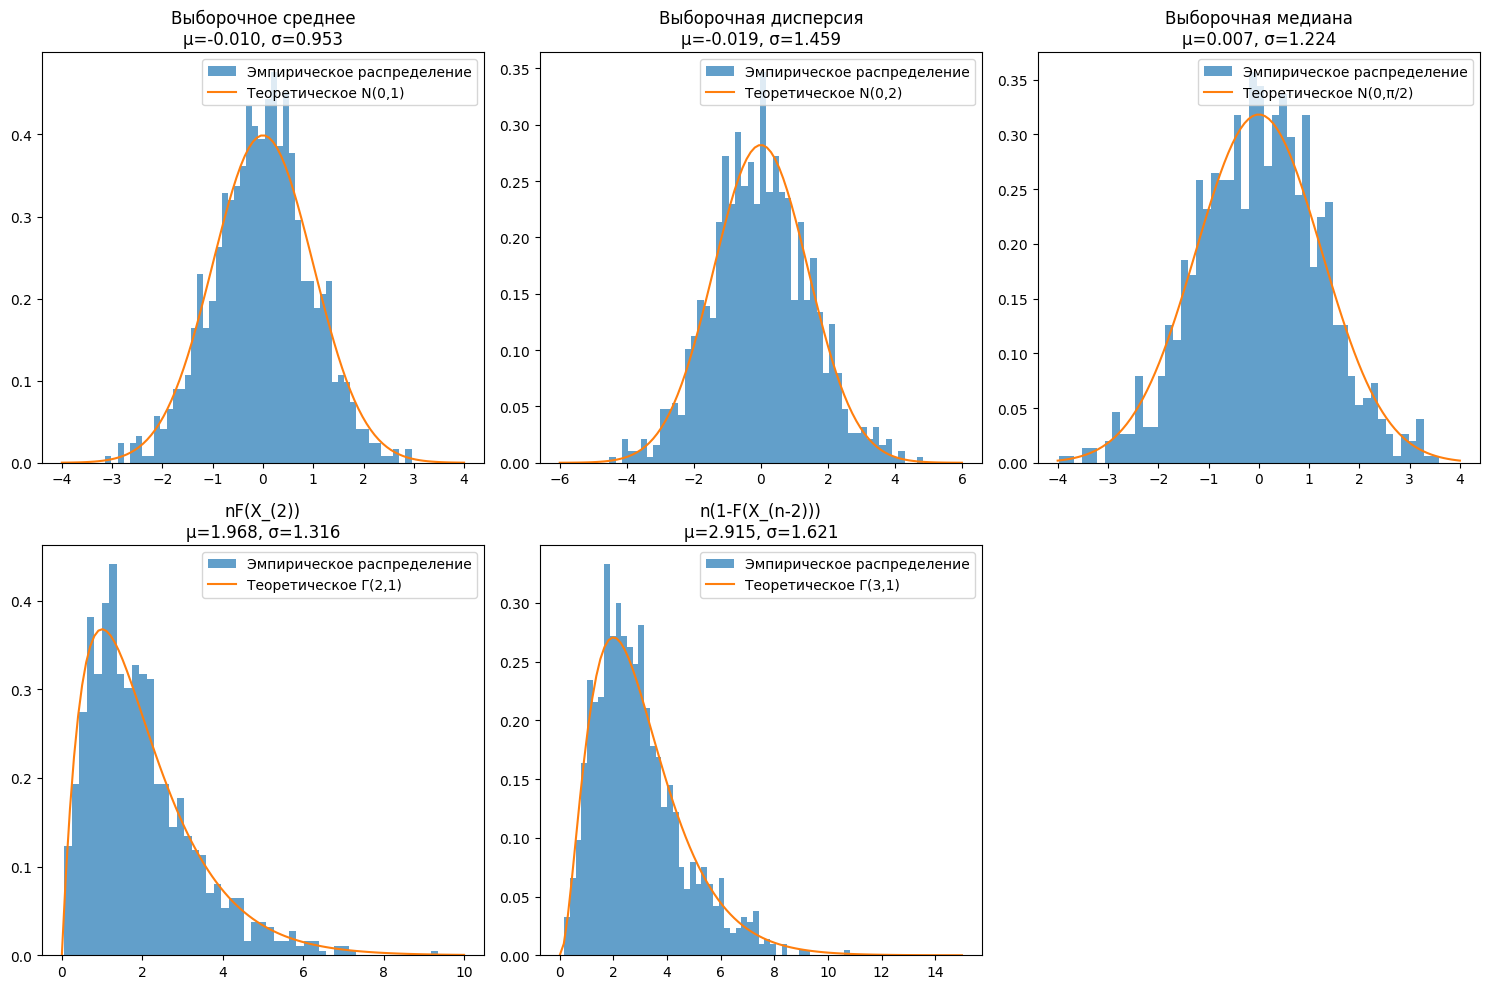

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

x = np.linspace(-4, 4, 100)
axes[0,0].hist(norm_means, bins=50, density=True, alpha=0.7, label='Эмпирическое распределение')
axes[0,0].plot(x, norm.pdf(x, 0, 1), label='Теоретическое N(0,1)')
axes[0,0].set_title(f'Выборочное среднее\nμ={np.mean(norm_means):.3f}, σ={np.std(norm_means):.3f}')
axes[0,0].legend()

x = np.linspace(-6, 6, 100)
axes[0,1].hist(norm_vars, bins=50, density=True, alpha=0.7, label='Эмпирическое распределение')
axes[0,1].plot(x, norm.pdf(x, 0, np.sqrt(2)), label='Теоретическое N(0,2)')
axes[0,1].set_title(f'Выборочная дисперсия\nμ={np.mean(norm_vars):.3f}, σ={np.std(norm_vars):.3f}')
axes[0,1].legend()

x = np.linspace(-4, 4, 100)
axes[0,2].hist(norm_medians, bins=50, density=True, alpha=0.7, label='Эмпирическое распределение')
axes[0,2].plot(x, norm.pdf(x, 0, np.sqrt(np.pi/2)), label='Теоретическое N(0,π/2)')
axes[0,2].set_title(f'Выборочная медиана\nμ={np.mean(norm_medians):.3f}, σ={np.std(norm_medians):.3f}')
axes[0,2].legend()

x = np.linspace(0, 10, 100)
axes[1,0].hist(U1, bins=50, density=True, alpha=0.7, label='Эмпирическое распределение')
axes[1,0].plot(x, gamma.pdf(x, 2, scale=1), label='Теоретическое Γ(2,1)')
axes[1,0].set_title(f'nF(X_(2))\nμ={np.mean(U1):.3f}, σ={np.std(U1):.3f}')
axes[1,0].legend()

x = np.linspace(0, 15, 100)
axes[1,1].hist(U2, bins=50, density=True, alpha=0.7, label='Эмпирическое распределение')
axes[1,1].plot(x, gamma.pdf(x, 3, scale=1), label='Теоретическое Γ(3,1)')
axes[1,1].set_title(f'n(1-F(X_(n-2)))\nμ={np.mean(U2):.3f}, σ={np.std(U2):.3f}')
axes[1,1].legend()

fig.delaxes(axes[1,2])
plt.tight_layout()
plt.show()